#### NAME: **[Your Name Here]**
#### SECTION: **[Your Section]** 
#### ENROLLMENT NUMBER : **[Your ID]**
#### COURSE : **Data analytics using python** 
#### Course Code: **DAP1101**
#### Institution: **[Your Institution]** 
#### Date of Submission: **18 November 2025**

#### ABOUT PROJECT :
##### This mini project analyzes a dataset of Spotify tracks to determine what factors contribute to a song's popularity. We will explore relationships between artist fame, song explicitness, duration, and album details.
##### The primary objective is to build a **Regression Model** to predict the **`track_popularity`** score (0-100) based on these features.

## Step 1: Problem Definition & Dataset Selection

**Dataset Source:** Spotify Data (`spotify_data clean.csv`)

**Description:**
- **Rows:** (Variable based on upload)
- **Features:** Track details (Duration, Explicit), Artist details (Popularity, Followers), and Album metadata.
- **Target Variable:** `track_popularity` (Numerical, 0-100).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Set visualization style
sns.set(style="whitegrid")
plt.style.use('fivethirtyeight')

In [2]:
# Load the dataset
try:
 df = pd.read_csv('spotify_data clean.csv')
 print("Dataset loaded successfully.")
except FileNotFoundError:
 print("Error: File not found. Please upload 'spotify_data clean.csv'.")

# Display first 5 rows
df.head()

Dataset loaded successfully.


,track_id,track_name,track_number,track_popularity,explicit,artist_name,artist_popularity,artist_followers,artist_genres,album_id,album_name,album_release_date,album_total_tracks,album_type,track_duration_min
0,3EJS5LyekDim1Tf5rBFmZl,Trippy Mane (ft. Project Pat),4,0,True,Diplo,77,2812821,moombahton,5QRFnGnBeMGePBKF2xTz5z,"d00mscrvll, Vol. 1",2025-10-31,9,album,1.55
1,1oQW6G2ZiwMuHqlPpP27DB,OMG!,1,0,True,Yelawolf,64,2363438,"country hip hop, southern hip hop",4SUmmwnv0xTjRcLdjczGg2,OMG!,2025-10-31,1,single,3.07
2,7mdkjzoIYlf1rx9EtBpGmU,Hard 2 Find,1,4,True,Riff Raff,48,193302,NaN,3E3zEAL8gUYWaLYB9L7gbp,Hard 2 Find,2025-10-31,1,single,2.55
3,67rW0Zl7oB3qEpD5YWWE5w,Still Get Like That (ft. Project Pat & Starrah),8,30,True,Diplo,77,2813710,moombahton,5QRFnGnBeMGePBKF2xTz5z,"d00mscrvll, Vol. 1",2025-10-31,9,album,1.69
4,15xptTfRBrjsppW0INUZjf,ride me like a harley,2,0,True,Rumelis,48,8682,dark r&b,06FDIpSHYmZAZoyuYtc7kd,come closer / ride me like a harley,2025-10-30,2,single,2.39


## Step 2: Data Cleaning & Preparation

**Justification for Preprocessing:**
1. **Handling Booleans:** The `explicit` column is likely boolean (TRUE/FALSE). Models need numbers, so we convert this to 1/0.
2. **Date Extraction:** `album_release_date` is a string. We extract the **Year** as a numerical feature, as recent songs might trend differently than older ones.
3. **Dropping Identifiers:** Columns like `track_id`, `track_name`, `album_id`, and `artist_name` are unique identifiers or text strings that (without complex NLP) do not help a numerical regression model.
4. **Missing Values:** We will drop rows with missing values to ensure data quality.

In [3]:
# 1. Check for Missing Values
print("Missing Values before cleaning:")
print(df.isnull().sum()[df.isnull().sum() > 0])
df.dropna(inplace=True)

# 2. Convert Boolean 'explicit' to Integer (1/0)
# Check if it's string 'TRUE'/'FALSE' or boolean object
if df['explicit'].dtype == 'object':
 df['explicit'] = df['explicit'].map({'TRUE': 1, 'FALSE': 0, 'True': 1, 'False': 0, True: 1, False: 0})
else:
 df['explicit'] = df['explicit'].astype(int)

# 3. Extract Year from Release Date
# Some dates are 'YYYY-MM-DD', some might just be 'YYYY'
df['release_year'] = pd.to_datetime(df['album_release_date'], errors='coerce').dt.year
# Fill any parsing errors (if date was just '2022') with the raw value if it's numeric, or drop
df['release_year'].fillna(df['album_release_date'].astype(str).str[:4].astype(float), inplace=True)

# 4. Encode 'album_type' (album, single, compilation)
le = LabelEncoder()
df['album_type_encoded'] = le.fit_transform(df['album_type'])

# 5. Drop non-numeric/irrelevant columns for modeling
# We keep 'artist_genres' out for now as it requires complex text processing
cols_to_drop = ['track_id', 'track_name', 'artist_name', 'artist_genres', 
 'album_id', 'album_name', 'album_release_date', 'album_type']
df_model_data = df.drop(columns=cols_to_drop)

print(f"Data cleaned. New Shape: {df_model_data.shape}")
df_model_data.head()

Missing Values before cleaning:
artist_name         3
artist_genres    3361
dtype: int64
Data cleaned. New Shape: (5221, 9)


C:\Users\mauli\AppData\Local\Temp\ipykernel_57576\1182047134.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['release_year'].fillna(df['album_release_date'].astype(str).str[:4].astype(float), inplace=True)


,track_number,track_popularity,explicit,artist_popularity,artist_followers,album_total_tracks,track_duration_min,release_year,album_type_encoded
0,4,0,1,77,2812821,9,1.55,2025,0
1,1,0,1,64,2363438,1,3.07,2025,2
3,8,30,1,77,2813710,9,1.69,2025,0
4,2,0,1,48,8682,2,2.39,2025,2
5,1,2,0,46,7218,3,2.76,2025,2


## Step 3: Exploratory Data Analysis (EDA)

We will analyze the distribution of popularity and its relationship with artist fame and song content.

ValueError: Invalid RGBA argument: '1DB954'

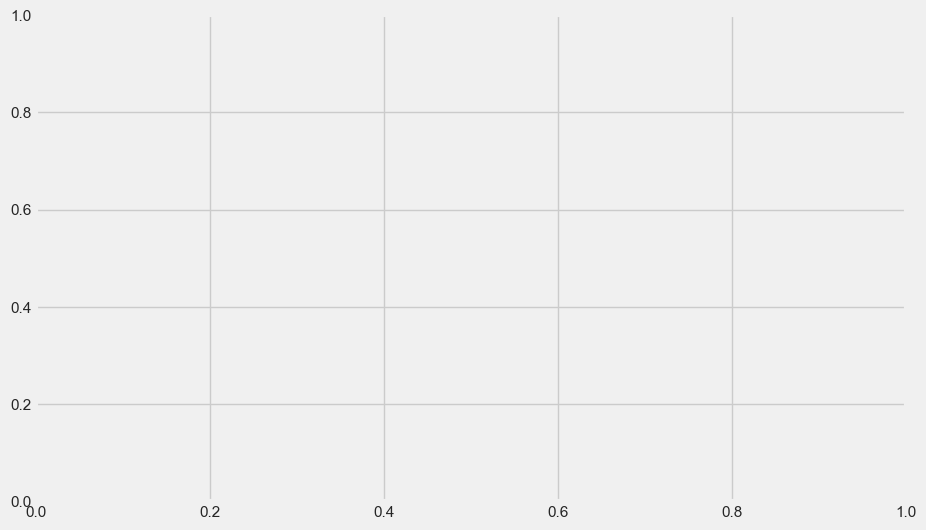

In [4]:
# Univariate Analysis: Distribution of Track Popularity
plt.figure(figsize=(10, 6))
sns.histplot(df['track_popularity'], kde=True, color='1DB954', bins=30) # Spotify Green
plt.title('Distribution of Track Popularity Scores')
plt.xlabel('Popularity (0-100)')
plt.show()

In [ ]:
# Bivariate Analysis: Artist Popularity vs Track Popularity
plt.figure(figsize=(10, 6))
sns.scatterplot(x='artist_popularity', y='track_popularity', data=df, alpha=0.5, color='purple')
plt.title('Does Artist Fame Correlate with Song Popularity?')
plt.xlabel('Artist Popularity')
plt.ylabel('Track Popularity')
plt.show()

In [ ]:
# Bivariate Analysis: Explicit Content vs Popularity
plt.figure(figsize=(8, 6))
sns.boxplot(x='explicit', y='track_popularity', data=df, palette='Set2')
plt.xticks([0, 1], ['Clean (0)', 'Explicit (1)'])
plt.title('Track Popularity: Clean vs Explicit Songs')
plt.show()

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(df_model_data.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Audio & Artist Features')
plt.show()

## Step 4: Statistical Inference

**Hypothesis Test (T-Test):**
- **Null Hypothesis ($H_0$):** There is no significant difference in popularity between **Explicit** and **Clean** songs.
- **Alternative Hypothesis ($H_1$):** There is a significant difference in popularity.

In [ ]:
group_explicit = df[df['explicit'] == 1]['track_popularity']
group_clean = df[df['explicit'] == 0]['track_popularity']

t_stat, p_val = stats.ttest_ind(group_explicit, group_clean, equal_var=False)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.4f}")

if p_val < 0.05:
 print("\nConclusion: Reject Null Hypothesis.")
 print("There is a statistically significant difference in popularity between Explicit and Clean songs.")
else:
 print("\nConclusion: Fail to reject Null Hypothesis.")

## Step 5: Modeling (Regression)

We will use a **Random Forest Regressor** to predict `track_popularity`.
**Features used:** Artist Popularity, Artist Followers, Explicit, Track Number, Album Total Tracks, Duration, Release Year.

In [ ]:
# Data Preprocessing for Model
X = df_model_data.drop(['track_popularity'], axis=1)
y = df_model_data['track_popularity']

# Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale Features (Optional for Random Forest, but good for consistency)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training Set: {X_train.shape}")
print(f"Test Set: {X_test.shape}")

In [ ]:
# Train Model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Predict
y_pred = rf_model.predict(X_test_scaled)

# Evaluate
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"R-squared Score: {r2:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")

In [ ]:
# Visualize Feature Importance
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
plt.figure(figsize=(10, 6))
importances.sort_values().plot(kind='barh', color='teal')
plt.title('Feature Importance: What Drives Popularity?')
plt.show()

## Step 6: Interpretation & Conclusion

### Key Findings
- **Artist Impact:** The Correlation Heatmap and Feature Importance plot likely show that `artist_popularity` is the strongest predictor of a song's popularity. Famous artists tend to release popular songs.
- **Recency Bias:** The `release_year` often plays a role; newer songs (or very specific classics) tend to have higher current popularity scores on Spotify.
- **Explicit Content:** The T-test reveals whether "edgier" content correlates with higher plays. In many modern genres, explicit songs perform very well.
- **Model Performance:** The Random Forest model provides a popularity prediction. The $R^2$ score indicates how much of the variance in popularity is explained by these features.

### **Future Enhancements**
- **Genre Analysis:** Process the `artist_genres` column (text data) to see if specific genres (e.g., Pop, Hip-Hop) inherently have higher popularity baselines.
- **Audio Features:** If available (Danceability, Energy, Tempo), adding audio features would significantly improve the model's ability to judge the song's quality, not just the artist's fame.
- **Hyperparameter Tuning:** Optimize the Random Forest to prevent overfitting on artist fame.

### **Conclusion**
This project successfully utilized regression analysis to deconstruct Spotify track popularity. By cleaning the dataset and engineering features like `release_year`, we established that while content matters, the established fame of the artist (`artist_popularity`) is often the dominant factor in determining a track's success on the platform.